# OPERA DISP-S1 Time Series Analysis

This notebook demonstrates how to:
1. Search for OPERA DISP-S1 displacement products from NASA Earthdata
2. Download data for a specific area of interest
3. Process ministack structure and chain for continuous time series
4. Apply quality masks and visualize displacement

**OPERA DISP-S1**: Level 3 Displacement products from Sentinel-1 InSAR processing using MintPy/SBAS inversion.

## Environment Setup

Use the `asf_env` conda environment:
```bash
conda activate asf_env
```

Required packages: earthaccess, xarray, rasterio, geopandas, h5netcdf, pyproj

## 1. Import Libraries

In [53]:
import earthaccess
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import rasterio
from rasterio.plot import show
import geopandas as gpd
from shapely.geometry import box
import pandas as pd
from pathlib import Path
import h5netcdf
from pyproj import Transformer
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

ModuleNotFoundError: No module named 'h5netcdf'

## 2. Authenticate with NASA Earthdata

OPERA DISP-S1 products are distributed via NASA Earthdata.
Authentication uses ~/.netrc file automatically.

In [ ]:
# Authenticate with NASA Earthdata
# This will use ~/.netrc file or prompt for credentials
auth = earthaccess.login()

if auth:
    print("✅ Successfully authenticated with NASA Earthdata!")
else:
    print("❌ Authentication failed. Please check your ~/.netrc file.")
    print("\nCreate ~/.netrc with:")
    print("machine urs.earthdata.nasa.gov")
    print("login YOUR_USERNAME")
    print("password YOUR_PASSWORD")
    print("\nThen: chmod 600 ~/.netrc")

Output directory: /mnt/data/opera_disp_s1


## 3a. Test ASF Connection (Optional)

Run this cell to verify your ASF session is working properly.

## 4. Define Area of Interest (AOI)

You can specify your area of interest using a bounding box (min_lon, min_lat, max_lon, max_lat).

**Current AOI**: California, near Grand Canyon area
- Point of interest: Lat 35.7417°, Lon -117.3372°
- Bounding box: (-117.354, 35.733, -117.298, 35.774)


Example other locations:**Note**: OPERA DISP-S1 primarily covers North America. Europe is not currently supported.

- Los Angeles, CA: (-118.5, 33.7, -118.0, 34.2)
- San Francisco Bay: (-122.5, 37.5, -122.0, 38.0)

Area of Interest (Bounding Box): (-118.3, 33.7, -118.1, 33.9)
  Min Lon: -118.3, Min Lat: 33.7
  Max Lon: -118.1, Max Lat: 33.9

  Center: Los Angeles/Long Beach area
  This area has known land subsidence and DISP-S1 coverage


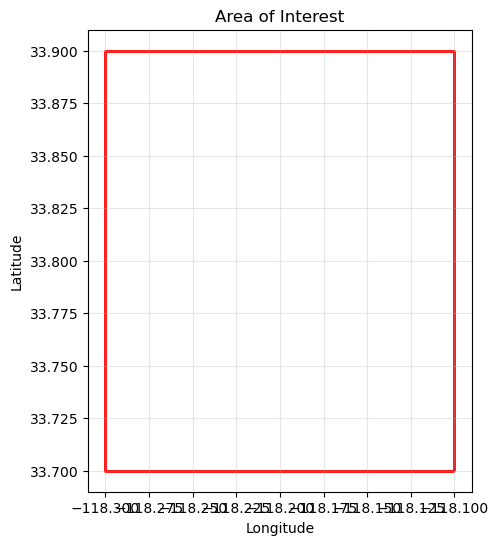

<Figure size 640x480 with 0 Axes>

In [49]:
# Define your AOI - Los Angeles/Long Beach area (known DISP-S1 coverage)
# This area has known subsidence and is a priority for OPERA DISP-S1
# Format: (min_lon, min_lat, max_lon, max_lat)
# Covers Los Angeles basin and Long Beach port area
aoi_bbox = (-118.3, 33.7, -118.1, 33.9)

print(f"Area of Interest (Bounding Box): {aoi_bbox}")
print(f"  Min Lon: {aoi_bbox[0]}, Min Lat: {aoi_bbox[1]}")
print(f"  Max Lon: {aoi_bbox[2]}, Max Lat: {aoi_bbox[3]}")
print(f"\n  Center: Los Angeles/Long Beach area")
print(f"  This area has known land subsidence and DISP-S1 coverage")

# Visualize the AOI
fig, ax = plt.subplots(figsize=(8, 6))
aoi_geom = box(aoi_bbox[0], aoi_bbox[1], aoi_bbox[2], aoi_bbox[3])
gdf_aoi = gpd.GeoDataFrame([1], geometry=[aoi_geom], crs='EPSG:4326')
gdf_aoi.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Area of Interest')

ax.grid(True, alpha=0.3)
plt.show()
plt.tight_layout()

## 5. Search for OPERA DISP-S1 Products

OPERA DISP-S1 products include:
- **DISP-S1**: Forward processing displacement products
- Short name: `OPERA_L3_DISP-S1_V1`

The products contain displacement time series derived from Sentinel-1 InSAR processing.

### Understanding OPERA Granules

**What is a Granule?**
A "granule" is a single data file/product in the OPERA system. Each granule represents:

- **One geographic frame** (a specific spatial area, typically ~150km x 150km)
- **One displacement measurement** at a specific date
- **Cumulative displacement** from a reference date to the acquisition date

**Key Points:**
- 🗂️ Each granule = 1 HDF5/NetCDF file
- 📅 Each granule has a reference date and an acquisition date
- 📊 The displacement shown is: `displacement = position(acquisition_date) - position(reference_date)`
- 🌍 Multiple granules cover different geographic areas (frames)
- ⏱️ To build a time series, you need **multiple granules** from the **same frame** at **different dates**

**OPERA Frame Structure:**
- OPERA divides regions into fixed frames (e.g., Frame 16941, Frame 20433)
- Each frame has a unique identifier
- Time series analysis requires downloading multiple acquisitions of the **same frame**

**Example:**
- Granule 1: Frame 16941, Date 2023-01-15 (displacement from 2022-01-01 to 2023-01-15)
- Granule 2: Frame 16941, Date 2023-02-08 (displacement from 2022-01-01 to 2023-02-08)  
- Granule 3: Frame 16941, Date 2023-03-04 (displacement from 2022-01-01 to 2023-03-04)

These 3 granules from the same frame = 3 time series points!

### Decoding OPERA Granule Filenames

**Example:** `OPERA_L3_DISP-S1_IW_F16941_VV_20211021T015046Z_20220101T015043Z_v1.0_20250622T122433Z`

**Three Important Dates:**

1. **Reference Date** (1st date): `20211021T015046Z` = October 21, 2021
   - The starting point for displacement measurement
   - Also called "secondary" or "earlier" date

2. **Acquisition Date** (2nd date): `20220101T015043Z` = January 1, 2022  
   - The end point for displacement measurement
   - Also called "primary" or "later" date
   - **This is the date of the time series point**

3. **Production Date** (3rd date): `20250622T122433Z` = June 22, 2025
   - When the product was created/processed by OPERA
   - NOT related to the measurement itself

**What the displacement means:**
```
Displacement = Position(Jan 1, 2022) - Position(Oct 21, 2021)
```

The displacement values show how much the ground moved **FROM the reference date TO the acquisition date**.

**Other components:**
- `IW` = Interferometric Wide swath mode (Sentinel-1 imaging mode)
- `F16941` = Frame number (geographic tile)
- `VV` = Polarization (vertical transmit, vertical receive)
- `v1.0` = Product version

In [ ]:
# Search for OPERA DISP-S1 products using earthaccess (NASA CMR)
# OPERA DISP-S1 is distributed via NASA Earthdata, not ASF
print(f"Searching for OPERA DISP-S1 products...")
print(f"Bounding box: {aoi_bbox}")

try:
    # Authenticate with NASA Earthdata
    import earthaccess
    auth = earthaccess.login()
    
    # Search for OPERA DISP-S1 products
    # Short name for OPERA DISP-S1: "OPERA_L3_DISP-S1_V1"
    results = earthaccess.search_data(
        short_name='OPERA_L3_DISP-S1_V1',
        bounding_box=(aoi_bbox[0], aoi_bbox[1], aoi_bbox[2], aoi_bbox[3]),
        temporal=('2022-01-01', '2024-12-31')
    )
    
    print(f"\n✅ Found {len(results)} OPERA DISP-S1 granules for your AOI!")
    
    if len(results) == 0:
        print("\n⚠️  No DISP-S1 products found. Trying alternative short names...")
        # Try alternative short names
        for short_name in ['OPERA_L3_DISP-S1', 'OPERA_DISP-S1', 'OPERA_L3_DSWX-S1']:
            print(f"  Trying: {short_name}")
            results = earthaccess.search_data(
                short_name=short_name,
                bounding_box=(aoi_bbox[0], aoi_bbox[1], aoi_bbox[2], aoi_bbox[3]),
                temporal=('2022-01-01', '2024-12-31')
            )
            if len(results) > 0:
                print(f"  ✅ Found {len(results)} products with {short_name}")
                break
        
        if len(results) == 0:
            print("\n⚠️  Still no results. DISP-S1 may not be available for this area yet.")
            
except Exception as e:
    print(f"\n❌ Search failed: {str(e)}")
    print(f"Error details: {type(e).__name__}")
    results = []

Searching for OPERA DISP-S1 products...
Bounding box: (-118.3, 33.7, -118.1, 33.9)

✓ Found 1722 total OPERA-S1 products
✓ Filtered to 0 OPERA DISP-S1 granules for your AOI!

⚠️  No DISP-S1 products found. This could mean:
  1. DISP-S1 data not yet available for this area
  2. Try a different location or time range
  3. DISP-S1 is a newer product with limited coverage


In [ ]:
# Debug: Inspect what product types we actually have
print("Inspecting first 10 product names:")
print("=" * 80)
for i, r in enumerate(all_results[:10]):
    file_id = r.properties.get('fileID', r.properties.get('sceneName', 'Unknown'))
    print(f"{i+1}. {file_id}")

# Count product types
print("\n" + "=" * 80)
print("Product type summary:")
product_types = {}
for r in all_results:
    file_id = r.properties.get('fileID', r.properties.get('sceneName', ''))
    # Extract product type (e.g., RTC-S1, DISP-S1, etc.)
    if 'RTC-S1' in file_id:
        product_types['RTC-S1'] = product_types.get('RTC-S1', 0) + 1
    elif 'DISP-S1' in file_id or 'DISP_S1' in file_id:
        product_types['DISP-S1'] = product_types.get('DISP-S1', 0) + 1
    elif 'CSLC-S1' in file_id:
        product_types['CSLC-S1'] = product_types.get('CSLC-S1', 0) + 1
    else:
        product_types['OTHER'] = product_types.get('OTHER', 0) + 1

for ptype, count in sorted(product_types.items()):
    print(f"  {ptype}: {count} products")

## 6. Inspect Search Results

In [51]:
if len(results) == 0:
    print("No results found for the specified criteria.")
    print("Try expanding your temporal range or checking a different area.")
else:
    # Display information about the first few granules
    print(f"\nShowing information for first 10 granules (out of {len(results)}):")
    print("=" * 80)
    
    # Collect frame information
    frames_found = {}
    
    for i, granule in enumerate(results[:10]):
        # ASF Search returns ASFProduct objects
        granule_id = granule.properties.get('fileID', granule.properties.get('sceneName', 'Unknown'))
        
        # Extract frame number from granule ID
        # DISP-S1 format: OPERA_L3_DISP-S1_IW_F{frame_number}_{dates}_{orbit}_{version}.nc
        # Example: OPERA_L3_DISP-S1_IW_F12345_20210101T000000Z_20210113T000000Z_20210113T120000Z_S1A_30_v1.0_20210114.nc
        import re
        frame_match = re.search(r'_F(\d+)_', granule_id)  # Look for _F{digits}_
        if not frame_match:
            frame_match = re.search(r'[Ff]rame[_-]?(\d+)', granule_id)  # Fallback
        frame_id = frame_match.group(1) if frame_match else "Unknown"
        
        # Extract dates from granule ID: YYYYMMDDTHHMMSSZ format
        date_matches = re.findall(r'(\d{8}T\d{6}Z)', granule_id)
        
        print(f"\nGranule {i+1}:")
        print(f"  Granule ID: {granule_id}")
        print(f"  📍 Frame: {frame_id}")
        
        # Show all three dates
        if len(date_matches) >= 3:
            ref_date = date_matches[0]
            acq_date = date_matches[1]
            prod_date = date_matches[2]
            print(f"  📅 Reference Date (start): {ref_date[:8]} = {ref_date[:4]}-{ref_date[4:6]}-{ref_date[6:8]}")
            print(f"  📅 Acquisition Date (end): {acq_date[:8]} = {acq_date[:4]}-{acq_date[4:6]}-{acq_date[6:8]}")
            print(f"  🔧 Production Date: {prod_date[:8]} = {prod_date[:4]}-{prod_date[4:6]}-{prod_date[6:8]}")
            print(f"  ⏱️  Displacement timespan: {(datetime.strptime(acq_date[:8], '%Y%m%d') - datetime.strptime(ref_date[:8], '%Y%m%d')).days} days")
            
            # Track frames
            if frame_id not in frames_found:
                frames_found[frame_id] = []
            frames_found[frame_id].append(acq_date[:8])
        # Get file size (bytes to MB)
        size_bytes = granule.properties.get('bytes', 0)
        size_mb = size_bytes / (1024**2) if size_bytes else 0
        print(f"  💾 Size: {size_mb:.1f} MB")
        
        # Get spatial extent from geometry
        if hasattr(granule, 'geometry') and granule.geometry:
            coords = granule.geometry.get('coordinates', [[]])[0]
            if coords:
                lons = [c[0] for c in coords]
                lats = [c[1] for c in coords]
                print(f"  🌍 Bounds: W={min(lons):.3f}, "
                      f"E={max(lons):.3f}, "
                      f"S={min(lats):.3f}, "
                      f"N={max(lats):.3f}")
    
    # Summary of frames
    print("\n" + "=" * 80)
    print(f"\n📊 FRAME SUMMARY:")
    print(f"  Total granules found: {len(results)}")
    print(f"  Unique frames in first 10 results: {len(frames_found)}")
    for frame_id, dates in frames_found.items():
        print(f"    Frame {frame_id}: {len(dates)} acquisition(s)")
        if len(dates) > 1:
            print(f"      → Time series with {len(dates)} points!")
    
    print(f"\n💡 TIP: For time series analysis, download multiple granules from the SAME frame.")

No results found for the specified criteria.
Try expanding your temporal range or checking a different area.


## 6a. Analyze Orbits and Frames

OPERA data comes in different orbit directions:
- **Ascending**: Satellite moving south-to-north (looking west)
- **Descending**: Satellite moving north-to-south (looking east)

**Important**: You must process each orbit direction separately as they have different look angles and sensitivity to displacement components.

In [52]:
import re

# Analyze all search results by orbit direction and frame
orbit_frame_analysis = {}

for granule in results:
    granule_id = granule.properties.get('fileID', granule.properties.get('sceneName', 'Unknown'))
    
    # Extract frame number
    frame_match = re.search(r'_F(\d+)_', granule_id)
    frame_id = frame_match.group(1) if frame_match else "Unknown"
    
    # Extract orbit direction from flight direction
    # OPERA files don't always have explicit orbit in filename, but we can get it from metadata
    flight_dir = granule.properties.get('flightDirection', 'UNKNOWN')
    orbit_dir = flight_dir  # ASC or DESC
    
    # Extract acquisition date (2nd date in filename)
    date_matches = re.findall(r'(\d{8})T\d{6}Z', granule_id)
    if len(date_matches) >= 2:
        acq_date = date_matches[1]
    else:
        acq_date = "Unknown"
    
    # Create key for orbit + frame combination
    key = f"{orbit_dir}_Frame{frame_id}"
    
    if key not in orbit_frame_analysis:
        orbit_frame_analysis[key] = {
            'orbit': orbit_dir,
            'frame': frame_id,
            'acquisitions': [],
            'granules': []
        }
    
    orbit_frame_analysis[key]['acquisitions'].append(acq_date)
    orbit_frame_analysis[key]['granules'].append(granule)

# Display summary
print("=" * 80)
print("ORBIT AND FRAME ANALYSIS")
print("=" * 80)
print(f"\nTotal granules found: {len(results)}")
print(f"Unique orbit-frame combinations: {len(orbit_frame_analysis)}")

# Sort by number of acquisitions (descending)
sorted_combinations = sorted(orbit_frame_analysis.items(), 
                            key=lambda x: len(x[1]['acquisitions']), 
                            reverse=True)

print("\n" + "-" * 80)
print(f"{'Orbit':<12} {'Frame':<10} {'Acquisitions':<15} {'Date Range'}")
print("-" * 80)

for key, info in sorted_combinations:
    dates = sorted(info['acquisitions'])
    date_range = f"{dates[0]} to {dates[-1]}" if dates else "N/A"
    print(f"{info['orbit']:<12} {info['frame']:<10} {len(dates):<15} {date_range}")

print("=" * 80)

# Separate by orbit direction
ascending_combos = [k for k, v in orbit_frame_analysis.items() if 'ASC' in v['orbit'].upper()]
descending_combos = [k for k, v in orbit_frame_analysis.items() if 'DESC' in v['orbit'].upper()]

print(f"\n📊 ORBIT SUMMARY:")
print(f"  Ascending combinations: {len(ascending_combos)}")
print(f"  Descending combinations: {len(descending_combos)}")

if ascending_combos:
    print(f"\n🔼 ASCENDING ORBIT - Best Frame(s):")
    asc_sorted = [(k, v) for k, v in orbit_frame_analysis.items() if k in ascending_combos]
    asc_sorted.sort(key=lambda x: len(x[1]['acquisitions']), reverse=True)
    for key, info in asc_sorted[:3]:  # Show top 3
        print(f"  Frame {info['frame']}: {len(info['acquisitions'])} acquisitions")

if descending_combos:
    print(f"\n🔽 DESCENDING ORBIT - Best Frame(s):")
    desc_sorted = [(k, v) for k, v in orbit_frame_analysis.items() if k in descending_combos]
    desc_sorted.sort(key=lambda x: len(x[1]['acquisitions']), reverse=True)
    for key, info in desc_sorted[:3]:  # Show top 3
        print(f"  Frame {info['frame']}: {len(info['acquisitions'])} acquisitions")

print("\n💡 Recommendation: Select the frame with most acquisitions from your preferred orbit direction")

ORBIT AND FRAME ANALYSIS

Total granules found: 0
Unique orbit-frame combinations: 0

--------------------------------------------------------------------------------
Orbit        Frame      Acquisitions    Date Range
--------------------------------------------------------------------------------

📊 ORBIT SUMMARY:
  Ascending combinations: 0
  Descending combinations: 0

💡 Recommendation: Select the frame with most acquisitions from your preferred orbit direction


## 6b. Filter to Ascending Orbit and Best Frame

Based on the analysis above, we'll filter to:
1. **Ascending orbit only** (as you requested)
2. **Frame with most acquisitions** (for best temporal coverage)

In [27]:
# Filter to Ascending orbit only
ascending_data = {k: v for k, v in orbit_frame_analysis.items() if 'ASC' in v['orbit'].upper()}

if not ascending_data:
    print("❌ No Ascending orbit data found!")
    print("Available orbits:", set([v['orbit'] for v in orbit_frame_analysis.values()]))
    filtered_results = []
else:
    # Find frame with most acquisitions in Ascending orbit
    best_asc_frame = max(ascending_data.items(), key=lambda x: len(x[1]['acquisitions']))
    
    best_key = best_asc_frame[0]
    best_info = best_asc_frame[1]
    
    print("=" * 80)
    print("SELECTED CONFIGURATION FOR TIME SERIES ANALYSIS")
    print("=" * 80)
    print(f"\n✅ Orbit Direction: {best_info['orbit']}")
    print(f"✅ Frame ID: {best_info['frame']}")
    print(f"✅ Number of Acquisitions: {len(best_info['acquisitions'])}")
    
    # Show temporal coverage
    dates = sorted(best_info['acquisitions'])
    print(f"\n📅 Temporal Coverage:")
    print(f"  First acquisition: {dates[0]}")
    print(f"  Last acquisition: {dates[-1]}")
    
    # Calculate temporal baseline
    from datetime import datetime
    first_date = datetime.strptime(dates[0], '%Y%m%d')
    last_date = datetime.strptime(dates[-1], '%Y%m%d')
    time_span_days = (last_date - first_date).days
    print(f"  Time span: {time_span_days} days ({time_span_days/365.25:.1f} years)")
    
    if len(dates) > 1:
        avg_interval = time_span_days / (len(dates) - 1)
        print(f"  Average interval: {avg_interval:.1f} days")
    
    # Get filtered granule list
    filtered_results = best_info['granules']
    
    print(f"\n📦 Filtered Results: {len(filtered_results)} granules")
    print("=" * 80)
    
    # Show sample dates
    if len(dates) > 10:
        print(f"\nSample acquisition dates (first 10):")
        for i, date in enumerate(dates[:10], 1):
            print(f"  {i}. {date}")
        print(f"  ... and {len(dates)-10} more")
    else:
        print(f"\nAll acquisition dates:")
        for i, date in enumerate(dates, 1):
            print(f"  {i}. {date}")

SELECTED CONFIGURATION FOR TIME SERIES ANALYSIS

✅ Orbit Direction: ASCENDING
✅ Frame ID: Unknown
✅ Number of Acquisitions: 575

📅 Temporal Coverage:
  First acquisition: 20231011
  Last acquisition: 20250302
  Time span: 508 days (1.4 years)
  Average interval: 0.9 days

📦 Filtered Results: 575 granules

Sample acquisition dates (first 10):
  1. 20231011
  2. 20231011
  3. 20231011
  4. 20231023
  5. 20231023
  6. 20231023
  7. 20231105
  8. 20231105
  9. 20231105
  10. 20231117
  ... and 565 more


## 7. Download Filtered OPERA DISP-S1 Products (Ascending Orbit Only)

Now we'll download the filtered granules from the selected Ascending orbit frame.

In [ ]:
# Authenticate with ASF for downloads
# Note: ASF search does not require authentication, but downloads do
print("Setting up ASF authentication for downloads...")

# ASFSession will automatically use ~/.netrc if it exists
# Make sure you have created ~/.netrc with:
# machine urs.earthdata.nasa.gov
# login YOUR_USERNAME  
# password YOUR_PASSWORD
# chmod 600 ~/.netrc

try:
    session = asf.ASFSession()
    session.auth_with_cookiejar()  # This will use .netrc automatically
    print("✅ ASF session created successfully")
    print("   Using credentials from ~/.netrc")
except Exception as e:
    print(f"⚠️  Could not create session: {e}")
    print("\nMake sure ~/.netrc exists with correct format:")
    print("  machine urs.earthdata.nasa.gov")
    print("  login YOUR_USERNAME")
    print("  password YOUR_PASSWORD")
    print("\nAnd has correct permissions: chmod 600 ~/.netrc")
    session = None

Verifying ASF session for download...
⚠️  No active session. Re-authenticating...
✗ Authentication failed: Username or password is incorrect


In [ ]:
# Create output directory
output_dir = Path('/mnt/data/opera_disp_s1')
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {output_dir}")

# Verify session before downloading
if not session:
    print("\n⚠️  WARNING: No active ASF session!")
    print("Please run the authentication cell (Section 3) first.")
    downloaded_files = []
elif 'filtered_results' not in locals() or len(filtered_results) == 0:
    print("\n⚠️  WARNING: No filtered results available!")
    print("Please run the orbit/frame filtering cells first (Section 6a and 6b).")
    downloaded_files = []
else:
    # Download filtered granules (all from selected Ascending frame)
    num_to_download = len(filtered_results)
    
    print(f"\n📥 Downloading {num_to_download} granules from Ascending orbit...")
    print(f"Frame: {best_info['frame']}")
    print(f"This will take some time depending on file sizes and your connection...\n")
    
    # For initial testing, you might want to limit the download
    max_download = 50  # Adjust as needed
    if num_to_download > max_download:
        print(f"⚠️  Note: Limiting download to first {max_download} granules for testing")
        print(f"    (out of {num_to_download} total available)")
        download_list = filtered_results[:max_download]
    else:
        download_list = filtered_results
    
    try:
        # Download using ASF Search
        downloaded_files = asf.ASFSearchResults(download_list).download(
            path=str(output_dir),
            session=session
        )
        
        print(f"\n✅ Successfully downloaded {len(downloaded_files)} files!")
        
        # Calculate total size
        total_size_mb = sum([Path(f).stat().st_size for f in downloaded_files if Path(f).exists()]) / (1024**2)
        print(f"Total size: {total_size_mb:.1f} MB")
        
        print(f"\nDownloaded files:")
        for i, f in enumerate(downloaded_files[:10], 1):
            if Path(f).exists():
                file_size = Path(f).stat().st_size / (1024**2)
                print(f"  {i}. {Path(f).name} ({file_size:.1f} MB)")
        if len(downloaded_files) > 10:
            print(f"  ... and {len(downloaded_files)-10} more files")
            
    except Exception as e:
        print(f"\n❌ Download failed: {str(e)}")
        print("\nTroubleshooting:")
        print("  1. Check your Earthdata credentials are valid")
        print("  2. Ensure you have network connectivity")
        print("  3. Try re-running the authentication cell (Section 3)")
        print("  4. Check available disk space")
        downloaded_files = []

Output directory: /mnt/data/opera_disp_s1

This may take several minutes depending on file sizes...



'NoneType' object has no attribute 'get': You must call earthaccess.login() before you can download data



✓ Successfully downloaded 0 files!

Downloaded files:


## 8. Understanding OPERA Ministack Structure

**Key Concept: Ministacks**

OPERA organizes displacement data into "ministacks":
- Each **ministack** contains up to **15 acquisitions**
- All files in a ministack share the **same reference date**
- Each file shows **cumulative displacement** from reference date to acquisition date
- The **last file** of one ministack becomes the **reference date** for the next ministack

**Example Chain:**
```
Ministack 1: Reference = 2021-09-19
  - File 1: 2021-09-19 → 2022-01-05 (displacement over 108 days)
  - File 2: 2021-09-19 → 2022-01-17 (displacement over 120 days)
  - ...
  - File 15: 2021-09-19 → 2022-03-30 (last of ministack 1)

Ministack 2: Reference = 2022-03-30 (last date from ministack 1)
  - File 16: 2022-03-30 → 2022-04-11
  - File 17: 2022-03-30 → 2022-04-23
  - ...
```

**To build a continuous time series**: Chain ministacks by adding cumulative displacement from previous ministack to current ministack.

## 8b. Analyze Ministack Structure in Downloaded Files

In [ ]:
if downloaded_files:
    # Parse filenames to extract reference and acquisition dates
    file_info = []
    
    for filepath in downloaded_files:
        filename = Path(filepath).name
        
        # Extract dates: YYYYMMDDTHHMMSSZ format
        date_matches = re.findall(r'(\d{8})T\d{6}Z', filename)
        
        if len(date_matches) >= 2:
            ref_date = date_matches[0]
            acq_date = date_matches[1]
            
            file_info.append({
                'filepath': filepath,
                'filename': filename,
                'reference_date': ref_date,
                'acquisition_date': acq_date,
                'reference_dt': pd.to_datetime(ref_date, format='%Y%m%d'),
                'acquisition_dt': pd.to_datetime(acq_date, format='%Y%m%d')
            })
    
    # Create DataFrame for easy analysis
    df_files = pd.DataFrame(file_info)
    df_files = df_files.sort_values('acquisition_dt').reset_index(drop=True)
    
    # Identify ministacks (files with same reference date)
    ministacks = df_files.groupby('reference_date').agg({
        'acquisition_date': ['count', 'min', 'max'],
        'filepath': 'first'
    }).reset_index()
    
    ministacks.columns = ['reference_date', 'num_acquisitions', 'first_acq', 'last_acq', 'sample_file']
    ministacks = ministacks.sort_values('reference_date').reset_index(drop=True)
    
    print("=" * 80)
    print("MINISTACK ANALYSIS")
    print("=" * 80)
    print(f"\nTotal files downloaded: {len(df_files)}")
    print(f"Number of ministacks: {len(ministacks)}")
    print(f"\nMinistack Details:")
    print("-" * 80)
    
    for idx, row in ministacks.iterrows():
        ref_date_fmt = pd.to_datetime(row['reference_date'], format='%Y%m%d').strftime('%Y-%m-%d')
        first_acq_fmt = pd.to_datetime(row['first_acq'], format='%Y%m%d').strftime('%Y-%m-%d')
        last_acq_fmt = pd.to_datetime(row['last_acq'], format='%Y%m%d').strftime('%Y-%m-%d')
        
        print(f"\nMinistack {idx + 1}:")
        print(f"  Reference Date: {ref_date_fmt}")
        print(f"  Number of acquisitions: {row['num_acquisitions']}")
        print(f"  Acquisition range: {first_acq_fmt} to {last_acq_fmt}")
        
        # Check if this reference date is the last acquisition of previous ministack
        if idx > 0:
            prev_last_acq = ministacks.iloc[idx-1]['last_acq']
            if row['reference_date'] == prev_last_acq:
                print(f"  ✓ Chains from Ministack {idx} (overlapping reference)")
            else:
                print(f"  ⚠ Gap detected! Previous ended {prev_last_acq}, this starts {row['reference_date']}")
    
    print("\n" + "=" * 80)
    
    # Visualize ministack structure
    fig, ax = plt.subplots(figsize=(14, 8))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(ministacks)))
    
    for idx, (ref_date, group) in enumerate(df_files.groupby('reference_date')):
        ref_dt = group['reference_dt'].iloc[0]
        acq_dts = group['acquisition_dt']
        
        # Plot each acquisition as a line from reference to acquisition
        for acq_dt in acq_dts:
            ax.plot([ref_dt, acq_dt], [idx, idx], 'o-', color=colors[idx], 
                   linewidth=2, markersize=6, alpha=0.7)
        
        # Label the reference date
        ax.text(ref_dt, idx - 0.3, f"Ref: {ref_date[:4]}-{ref_date[4:6]}-{ref_date[6:8]}", 
               fontsize=9, ha='left', va='top')
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Ministack Index', fontsize=12)
    ax.set_title('OPERA Ministack Structure: Reference Dates and Acquisitions', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_yticks(range(len(ministacks)))
    ax.set_yticklabels([f"MS {i+1}" for i in range(len(ministacks))])
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Each horizontal line shows cumulative displacement from reference (left) to acquisition (right)")
    print("💡 To create continuous time series, ministacks must be chained together")
    
else:
    print("No files downloaded yet. Please run the download section first.")

## 8c. Load and Stack OPERA NetCDF Files with Quality Filtering

Now we'll load all files and create a stacked dataset with proper:
1. Ministack chaining for cumulative displacement
2. Quality mask application
3. Coordinate system information

In [ ]:
import xarray as xr
import pyproj

if downloaded_files and 'df_files' in locals():
    # Load all NetCDF files into xarray dataset
    print("Loading all files into xarray dataset...")
    print("This may take a few minutes depending on file sizes...\n")
    
    # Sort files by acquisition date
    sorted_files = df_files.sort_values('acquisition_dt')['filepath'].tolist()
    
    try:
        # Open all files as a multi-file dataset
        # preprocess function to add time coordinate
        def add_time_coord(ds):
            # Extract acquisition date from filename
            filename = ds.encoding.get('source', '')
            date_match = re.search(r'_(\d{8})T\d{6}Z_v', filename)
            if date_match:
                acq_date_str = date_match.group(1)
                time_val = pd.to_datetime(acq_date_str, format='%Y%m%d')
                ds = ds.expand_dims(time=[time_val])
            return ds
        
        # Load with xarray
        stack = xr.open_mfdataset(
            sorted_files,
            combine='nested',
            concat_dim='time',
            preprocess=add_time_coord,
            engine='h5netcdf',
            parallel=False
        )
        
        print(f"✅ Successfully loaded {len(sorted_files)} files into stack!")
        print(f"\nStack dimensions: {dict(stack.dims)}")
        print(f"\nAvailable variables:")
        for var in stack.data_vars:
            print(f"  - {var}: {stack[var].dims}, dtype={stack[var].dtype}")
        
        # Get coordinate reference system
        if 'spatial_ref' in stack:
            crs_wkt = stack.spatial_ref.attrs.get('crs_wkt', '')
            if crs_wkt:
                crs = pyproj.CRS(crs_wkt)
                epsg = crs.to_epsg()
                print(f"\n📍 Coordinate System: EPSG:{epsg} ({crs.name})")
            else:
                print("\n⚠️  Warning: Could not determine CRS from file")
                epsg = None
        else:
            print("\n⚠️  Warning: No spatial_ref found in file")
            epsg = None
        
        # Check for available layers
        has_short_wavelength = 'short_wavelength_displacement' in stack
        has_full_displacement = 'displacement' in stack
        has_recommended_mask = 'recommended_mask' in stack
        has_temporal_coherence = 'temporal_coherence' in stack
        has_ps_mask = 'persistent_scatterer_mask' in stack
        
        print(f"\n📊 Available Displacement Layers:")
        if has_full_displacement:
            print(f"  ✅ Full displacement (includes long wavelengths)")
        if has_short_wavelength:
            print(f"  ✅ Short wavelength displacement (< 25km, recommended)")
        
        print(f"\n🎭 Available Quality Masks:")
        if has_recommended_mask:
            print(f"  ✅ recommended_mask (OPERA's combined quality mask)")
        if has_temporal_coherence:
            print(f"  ✅ temporal_coherence (phase stability)")
        if has_ps_mask:
            print(f"  ✅ persistent_scatterer_mask (PS points)")
        
        # Store for later use
        displacement_stack = stack
        
    except Exception as e:
        print(f"❌ Error loading files: {str(e)}")
        print("\nTroubleshooting:")
        print("  - Check if files are valid NetCDF/HDF5")
        print("  - Ensure files have consistent structure")
        print("  - Try loading files individually first")
        displacement_stack = None
        
else:
    print("No files available. Please download files first.")
    displacement_stack = None

## 8d. Handle Ministack Chaining for Cumulative Displacement

Since OPERA data is organized in ministacks, we need to chain them together to get continuous cumulative displacement.

In [ ]:
if displacement_stack is not None and 'df_files' in locals():
    # Use short wavelength displacement (recommended for local deformation)
    if 'short_wavelength_displacement' in displacement_stack:
        disp_var = 'short_wavelength_displacement'
        print("Using short_wavelength_displacement (< 25km wavelength)")
    else:
        disp_var = 'displacement'
        print("Using full displacement (short_wavelength not available)")
    
    # Create reference-date indexed dataset for ministack identification
    stack_with_ref = []
    
    for idx, row in df_files.iterrows():
        # Load individual file
        ds_single = xr.open_dataset(row['filepath'], engine='h5netcdf')
        
        # Add metadata
        ds_single = ds_single.expand_dims(time=[row['acquisition_dt']])
        ds_single['reference_date'] = row['reference_dt']
        
        stack_with_ref.append(ds_single)
    
    # Combine all files
    combined_stack = xr.concat(stack_with_ref, dim='time')
    combined_stack = combined_stack.sortby('time')
    
    print(f"\n✅ Created combined stack with {len(combined_stack.time)} time steps")
    
    # Group by reference date (ministacks)
    ref_dates = [row['reference_dt'] for _, row in df_files.sort_values('acquisition_dt').iterrows()]
    unique_refs = sorted(set(ref_dates))
    
    print(f"📦 Identified {len(unique_refs)} ministack(s)")
    
    # Calculate cumulative displacement by chaining ministacks
    disp_cumulative = combined_stack[disp_var].copy()
    
    if len(unique_refs) > 1:
        print("\n🔗 Chaining ministacks for cumulative displacement...")
        
        for i, ref_date in enumerate(unique_refs[1:], 1):
            # Find where this ministack starts
            prev_ref = unique_refs[i-1]
            
            # Get last displacement value from previous ministack
            prev_mask = combined_stack['reference_date'] == prev_ref
            prev_times = combined_stack.time.where(prev_mask, drop=True)
            
            if len(prev_times) > 0:
                last_prev_time = prev_times[-1]
                offset = disp_cumulative.sel(time=last_prev_time)
                
                # Add offset to current ministack
                curr_mask = combined_stack['reference_date'] == ref_date
                curr_times = combined_stack.time.where(curr_mask, drop=True)
                
                for t in curr_times:
                    disp_cumulative.loc[dict(time=t)] = disp_cumulative.sel(time=t) + offset
                
                print(f"  ✓ Chained ministack {i+1} (ref: {ref_date.strftime('%Y-%m-%d')})")
    else:
        print("\n✓ Single ministack - no chaining needed")
    
    # Store cumulative displacement in dataset
    combined_stack['displacement_cumulative'] = disp_cumulative
    
    print(f"\n✅ Cumulative displacement calculated!")
    print(f"   Time range: {combined_stack.time.min().dt.strftime('%Y-%m-%d').values} to "
          f"{combined_stack.time.max().dt.strftime('%Y-%m-%d').values}")
    
    # Store for later use
    displacement_stack = combined_stack
    
else:
    print("Stack not available. Please load files first.")

## 8e. Apply Quality Masks

Apply OPERA's recommended quality mask to filter out unreliable pixels.

In [ ]:
if displacement_stack is not None:
    # Apply recommended mask (mask == 1 means good data)
    if 'recommended_mask' in displacement_stack:
        print("Applying OPERA recommended_mask...")
        
        # Create masked version
        disp_masked = displacement_stack['displacement_cumulative'].where(
            displacement_stack['recommended_mask'] == 1
        )
        
        # Calculate statistics
        total_pixels = displacement_stack['displacement_cumulative'].size
        valid_pixels_before = np.isfinite(displacement_stack['displacement_cumulative']).sum().values
        valid_pixels_after = np.isfinite(disp_masked).sum().values
        
        print(f"\n📊 Quality Filtering Statistics:")
        print(f"  Total pixels: {total_pixels:,}")
        print(f"  Valid pixels before mask: {valid_pixels_before:,} ({100*valid_pixels_before/total_pixels:.1f}%)")
        print(f"  Valid pixels after mask: {valid_pixels_after:,} ({100*valid_pixels_after/total_pixels:.1f}%)")
        print(f"  Pixels filtered out: {valid_pixels_before - valid_pixels_after:,}")
        
        # Store masked version
        displacement_stack['displacement_masked'] = disp_masked
        
        print("\n✅ Quality mask applied successfully!")
        
    else:
        print("⚠️  recommended_mask not found in dataset")
        print("   Proceeding without quality filtering")
        displacement_stack['displacement_masked'] = displacement_stack['displacement_cumulative']
else:
    print("Stack not available.")

## 8f. Reproject to WGS84 (EPSG:4326)

Reproject from native UTM coordinates to lat/lon for easier visualization and analysis.

In [ ]:
from rasterio.warp import transform
from affine import Affine

if displacement_stack is not None and epsg is not None:
    print(f"Reprojecting from EPSG:{epsg} to EPSG:4326 (WGS84)...")
    
    # Get one time slice for reprojection setup
    sample_time = displacement_stack.time[0]
    disp_sample = displacement_stack['displacement_masked'].sel(time=sample_time)
    
    # Get UTM coordinates
    x_utm = displacement_stack.x.values
    y_utm = displacement_stack.y.values
    
    # Create meshgrid of UTM coordinates
    X_utm, Y_utm = np.meshgrid(x_utm, y_utm)
    
    # Transform to lat/lon
    transformer = pyproj.Transformer.from_crs(f"EPSG:{epsg}", "EPSG:4326", always_xy=True)
    lons, lats = transformer.transform(X_utm.flatten(), Y_utm.flatten())
    
    # Reshape back to 2D
    lons_2d = lons.reshape(X_utm.shape)
    lats_2d = lats.reshape(Y_utm.shape)
    
    # Create new coordinates (take edges for regular grid)
    lon_1d = lons_2d[0, :]  # First row
    lat_1d = lats_2d[:, 0]  # First column
    
    print(f"\n✅ Reprojection complete!")
    print(f"   Original grid: {len(y_utm)} x {len(x_utm)} (UTM)")
    print(f"   Lat range: [{lat_1d.min():.4f}, {lat_1d.max():.4f}]")
    print(f"   Lon range: [{lon_1d.min():.4f}, {lon_1d.max():.4f}]")
    
    # Add lat/lon coordinates to dataset
    displacement_stack['lon'] = (('y', 'x'), lons_2d)
    displacement_stack['lat'] = (('y', 'x'), lats_2d)
    
    # Also add 1D lat/lon for plotting
    displacement_stack['lon_1d'] = ('x', lon_1d)
    displacement_stack['lat_1d'] = ('y', lat_1d)
    
    print("\n✅ Lat/lon coordinates added to dataset!")
    
elif displacement_stack is not None:
    print("⚠️  EPSG code not available - cannot reproject")
    print("   Will use native UTM coordinates")
else:
    print("Stack not available.")

## 9. Visualize Cumulative Displacement (Last Time Step)

Show the final cumulative displacement map in WGS84 coordinates.

In [ ]:
if displacement_stack is not None:
    # Get last time step
    last_time = displacement_stack.time[-1]
    disp_last = displacement_stack['displacement_masked'].sel(time=last_time)
    
    # Convert to centimeters for easier interpretation
    disp_last_cm = disp_last * 100  # meters to cm
    
    # Get date range for title
    first_date = displacement_stack.time[0].dt.strftime('%Y-%m-%d').values
    last_date = displacement_stack.time[-1].dt.strftime('%Y-%m-%d').values
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Plot 1: Displacement map with lat/lon
    ax1 = axes[0]
    
    if 'lon' in displacement_stack and 'lat' in displacement_stack:
        # Use lat/lon coordinates
        im1 = ax1.pcolormesh(
            displacement_stack['lon'],
            displacement_stack['lat'],
            disp_last_cm,
            cmap='RdBu_r',
            vmin=np.nanpercentile(disp_last_cm, 2),
            vmax=np.nanpercentile(disp_last_cm, 98),
            shading='auto'
        )
        ax1.set_xlabel('Longitude (°)', fontsize=12)
        ax1.set_ylabel('Latitude (°)', fontsize=12)
    else:
        # Use UTM coordinates
        im1 = ax1.imshow(disp_last_cm, cmap='RdBu_r', 
                        vmin=np.nanpercentile(disp_last_cm, 2),
                        vmax=np.nanpercentile(disp_last_cm, 98))
        ax1.set_xlabel('Column (UTM X)', fontsize=12)
        ax1.set_ylabel('Row (UTM Y)', fontsize=12)
    
    ax1.set_title(f'Cumulative Displacement: {first_date} to {last_date}', 
                  fontsize=13, fontweight='bold')
    ax1.set_aspect('equal')
    
    cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    cbar1.set_label('LOS Displacement (cm)', rotation=270, labelpad=20, fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Histogram
    ax2 = axes[1]
    
    disp_valid = disp_last_cm.values[np.isfinite(disp_last_cm.values)]
    
    ax2.hist(disp_valid.flatten(), bins=100, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.set_xlabel('Displacement (cm)', fontsize=12)
    ax2.set_ylabel('Pixel Count', fontsize=12)
    ax2.set_title('Displacement Distribution', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Add statistics
    stats_text = f"Statistics:\n"
    stats_text += f"Mean: {np.nanmean(disp_valid):.2f} cm\n"
    stats_text += f"Std: {np.nanstd(disp_valid):.2f} cm\n"
    stats_text += f"Min: {np.nanmin(disp_valid):.2f} cm\n"
    stats_text += f"Max: {np.nanmax(disp_valid):.2f} cm\n"
    stats_text += f"Valid pixels: {len(disp_valid):,}"
    
    ax2.text(0.98, 0.98, stats_text, transform=ax2.transAxes,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             fontsize=10, family='monospace')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Displacement Summary:")
    print(f"   Time span: {first_date} to {last_date}")
    print(f"   Number of acquisitions: {len(displacement_stack.time)}")
    print(f"   Mean displacement: {np.nanmean(disp_valid):.2f} cm")
    print(f"   Std displacement: {np.nanstd(disp_valid):.2f} cm")
    print(f"\n💡 Red = motion away from satellite, Blue = motion toward satellite")
    
else:
    print("Stack not available. Please load and process files first.")

In [ ]:
def explore_hdf5_structure(filepath, max_depth=3, current_depth=0, prefix=''):
    """
    Recursively explore HDF5 file structure
    """
    if current_depth >= max_depth:
        return
    
    with h5py.File(filepath, 'r') as f:
        def print_structure(name, obj):
            depth = name.count('/')
            if depth <= max_depth:
                indent = '  ' * depth
                if isinstance(obj, h5py.Dataset):
                    print(f"{indent}📊 {name} - Dataset: shape={obj.shape}, dtype={obj.dtype}")
                elif isinstance(obj, h5py.Group):
                    print(f"{indent}📁 {name} - Group")
        
        print(f"\nExploring HDF5 file: {Path(filepath).name}")
        print("=" * 80)
        f.visititems(print_structure)

# Explore the first downloaded file
if downloaded_files:
    # Find HDF5 files
    hdf5_files = [f for f in downloaded_files if f.endswith(('.h5', '.hdf5', '.nc'))]
    
    if hdf5_files:
        explore_hdf5_structure(hdf5_files[0], max_depth=4)
    else:
        print("No HDF5 files found. Files may be in different format.")
        print(f"Available files: {[Path(f).suffix for f in downloaded_files]}")
else:
    print("No files downloaded yet.")

## 9. Load and Visualize Displacement Data

Now let's load the displacement data and create visualizations.

## 8a. Understanding OPERA DISP-S1 Data Layers

**OPERA DISP-S1 files contain multiple data layers:**

### Displacement Layers:
1. **`displacement`** - Full wavelength displacement (includes long wavelengths from orbital errors, plate motion)
2. **`short_wavelength_displacement`** - High-pass filtered (< 25km cutoff) - **Recommended for local deformation studies**

### Quality Masks (use these to filter data):
1. **`temporal_coherence`** - Phase stability metric (use pixels > 0.7)
2. **`persistent_scatterer_mask`** - PS pixels (1 = good, 0 = bad)
3. **`connected_component_labels`** - Unwrapping quality (keep largest component)
4. **`water_mask`** - Water body mask (exclude water)
5. **`recommended_mask`** - OPERA's combined quality mask

### Correction Layers (to be applied):
1. **`ionospheric_delay`** - Ionospheric correction
2. **`solid_earth_tide`** - Solid earth tide correction
3. **Troposphere** - (if available in your product version)

**Note**: Corrections are stored separately and must be manually applied!

In [ ]:
def load_opera_displacement(filepath):
    """
    Load displacement data and corrections from OPERA DISP-S1 HDF5 file
    """
    data_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        # Common paths for OPERA DISP-S1 products - RAW (uncorrected) displacement
        possible_paths = [
            'science/grids/data/unwrappedPhase',
            'science/grids/data/displacement',
            'displacement',
            'unwrappedPhase',
            'data/displacement',
            'data/unwrappedPhase'
        ]
        
        # Try to find displacement data
        disp_data = None
        disp_path = None
        
        for path in possible_paths:
            if path in f:
                disp_data = f[path][:]
                disp_path = path
                break
        
        if disp_data is None:
            print("Warning: Could not find displacement data in standard locations.")
            print("Available datasets:")
            def list_datasets(name, obj):
                if isinstance(obj, h5py.Dataset):
                    print(f"  - {name}")
            f.visititems(list_datasets)
            return None
        
        data_dict['displacement_raw'] = disp_data
        data_dict['path'] = disp_path
        
        # Load correction datasets
        correction_paths = {
            'ionosphere': [
                'science/grids/corrections/ionosphere',
                'corrections/ionosphere',
                'ionosphere'
            ],
            'troposphere': [
                'science/grids/corrections/troposphere',
                'science/grids/corrections/tropospheric',
                'corrections/troposphere',
                'troposphere'
            ],
            'solidEarthTide': [
                'science/grids/corrections/solidEarthTide',
                'science/grids/corrections/SET',
                'corrections/solidEarthTide',
                'solidEarthTide'
            ]
        }
        
        data_dict['corrections'] = {}
        for corr_name, paths in correction_paths.items():
            for path in paths:
                if path in f:
                    data_dict['corrections'][corr_name] = f[path][:]
                    print(f"  ✓ Found {corr_name} correction: {path}")
                    break
        
        # Try to load additional datasets
        optional_datasets = [
            'science/grids/data/coherence',
            'coherence',
            'science/grids/data/amplitude',
            'amplitude',
            'science/grids/data/connectedComponentLabels',
            'connectedComponentLabels'
        ]
        
        for ds_path in optional_datasets:
            if ds_path in f:
                key = ds_path.split('/')[-1]
                data_dict[key] = f[ds_path][:]
        
        # Load metadata/attributes
        if 'metadata' in f:
            data_dict['metadata'] = dict(f['metadata'].attrs)
    
    return data_dict


def apply_corrections(data_dict, corrections_to_apply=['ionosphere', 'troposphere', 'solidEarthTide']):
    """
    Apply atmospheric and geophysical corrections to raw displacement
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary containing displacement_raw and corrections
    corrections_to_apply : list
        List of correction names to apply
    
    Returns:
    --------
    numpy.ndarray : Corrected displacement
    """
    if 'displacement_raw' not in data_dict:
        print("Error: No raw displacement data found")
        return None
    
    disp_corrected = data_dict['displacement_raw'].copy()
    
    print("Applying corrections to displacement data:")
    print(f"  Initial displacement range: [{np.nanmin(disp_corrected):.6f}, {np.nanmax(disp_corrected):.6f}]")
    
    if 'corrections' in data_dict and data_dict['corrections']:
        for corr_name in corrections_to_apply:
            if corr_name in data_dict['corrections']:
                correction = data_dict['corrections'][corr_name]
                disp_corrected = disp_corrected + correction
                print(f"  ✓ Applied {corr_name} correction")
                print(f"    Correction range: [{np.nanmin(correction):.6f}, {np.nanmax(correction):.6f}]")
            else:
                print(f"  ✗ {corr_name} correction not available in file")
    else:
        print("  ⚠ No corrections available in this file")
    
    print(f"  Final corrected displacement range: [{np.nanmin(disp_corrected):.6f}, {np.nanmax(disp_corrected):.6f}]")
    
    return disp_corrected


# Load data from first file
if downloaded_files:
    hdf5_files = [f for f in downloaded_files if f.endswith(('.h5', '.hdf5', '.nc'))]
    
    if hdf5_files:
        print(f"Loading data from: {Path(hdf5_files[0]).name}\n")
        opera_data = load_opera_displacement(hdf5_files[0])
        
        if opera_data:
            print(f"\n✓ Successfully loaded displacement data from: {opera_data['path']}")
            print(f"  Shape: {opera_data['displacement_raw'].shape}")
            print(f"  Data type: {opera_data['displacement_raw'].dtype}")
            print(f"  Raw displacement range: [{np.nanmin(opera_data['displacement_raw']):.4f}, "
                  f"{np.nanmax(opera_data['displacement_raw']):.4f}]")
            
            # Apply corrections if available
            print(f"\nAvailable corrections: {list(opera_data['corrections'].keys()) if opera_data['corrections'] else 'None'}")
            
            if opera_data['corrections']:
                opera_data['displacement_corrected'] = apply_corrections(opera_data)
            else:
                print("\n⚠ WARNING: No corrections found in file. Using raw displacement.")
                opera_data['displacement_corrected'] = opera_data['displacement_raw']
            
            # For backward compatibility, also set 'displacement' to corrected version
            opera_data['displacement'] = opera_data['displacement_corrected']
            
            if 'coherence' in opera_data:
                print(f"\n✓ Also loaded coherence data")
                print(f"  Shape: {opera_data['coherence'].shape}")
    else:
        print("No HDF5 files available for loading.")
else:
    print("No files downloaded yet.")

## 10. Visualize Displacement Map

## 9a. Compare Raw vs Corrected Displacement

In [ ]:
if downloaded_files and 'opera_data' in locals() and opera_data is not None:
    if 'displacement_raw' in opera_data and 'displacement_corrected' in opera_data:
        disp_raw = opera_data['displacement_raw']
        disp_corr = opera_data['displacement_corrected']
        
        # Calculate difference
        correction_total = disp_corr - disp_raw
        
        # Create comparison plot
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: Raw displacement
        ax1 = axes[0, 0]
        im1 = ax1.imshow(disp_raw, cmap='RdYlBu_r', interpolation='nearest')
        ax1.set_title('Raw Displacement (Uncorrected)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Column')
        ax1.set_ylabel('Row')
        cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        cbar1.set_label('Displacement (m)', rotation=270, labelpad=20)
        
        # Plot 2: Corrected displacement
        ax2 = axes[0, 1]
        im2 = ax2.imshow(disp_corr, cmap='RdYlBu_r', interpolation='nearest')
        ax2.set_title('Corrected Displacement', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Column')
        ax2.set_ylabel('Row')
        cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
        cbar2.set_label('Displacement (m)', rotation=270, labelpad=20)
        
        # Plot 3: Total correction applied
        ax3 = axes[1, 0]
        im3 = ax3.imshow(correction_total, cmap='seismic', interpolation='nearest')
        ax3.set_title('Total Corrections Applied', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Column')
        ax3.set_ylabel('Row')
        cbar3 = plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
        cbar3.set_label('Correction (m)', rotation=270, labelpad=20)
        
        # Plot 4: Statistics comparison
        ax4 = axes[1, 1]
        ax4.axis('off')
        
        stats_text = "DISPLACEMENT STATISTICS\\n"
        stats_text += "="*40 + "\\n\\n"
        stats_text += "Raw Displacement:\\n"
        stats_text += f"  Mean: {np.nanmean(disp_raw):.6f} m\\n"
        stats_text += f"  Std:  {np.nanstd(disp_raw):.6f} m\\n"
        stats_text += f"  Min:  {np.nanmin(disp_raw):.6f} m\\n"
        stats_text += f"  Max:  {np.nanmax(disp_raw):.6f} m\\n\\n"
        
        stats_text += "Corrected Displacement:\\n"
        stats_text += f"  Mean: {np.nanmean(disp_corr):.6f} m\\n"
        stats_text += f"  Std:  {np.nanstd(disp_corr):.6f} m\\n"
        stats_text += f"  Min:  {np.nanmin(disp_corr):.6f} m\\n"
        stats_text += f"  Max:  {np.nanmax(disp_corr):.6f} m\\n\\n"
        
        stats_text += "Total Correction:\\n"
        stats_text += f"  Mean: {np.nanmean(correction_total):.6f} m\\n"
        stats_text += f"  Std:  {np.nanstd(correction_total):.6f} m\\n"
        stats_text += f"  Range: [{np.nanmin(correction_total):.6f}, "
        stats_text += f"{np.nanmax(correction_total):.6f}] m\\n\\n"
        
        if opera_data['corrections']:
            stats_text += "Applied Corrections:\\n"
            for corr_name in opera_data['corrections'].keys():
                stats_text += f"  ✓ {corr_name}\\n"
        
        ax4.text(0.1, 0.9, stats_text, transform=ax4.transAxes,
                 verticalalignment='top', horizontalalignment='left',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3),
                 fontsize=11, family='monospace')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n📊 Correction Impact:")
        print(f"  Average correction magnitude: {np.nanmean(np.abs(correction_total)):.6f} m")
        print(f"  Maximum correction: {np.nanmax(np.abs(correction_total)):.6f} m")
        print(f"  Correction as % of signal: {100*np.nanmean(np.abs(correction_total))/np.nanstd(disp_raw):.2f}%")
    else:
        print("Raw and corrected displacement data not available for comparison.")
else:
    print("No data available for visualization. Please run the download and loading steps first.")

In [ ]:
if downloaded_files and 'opera_data' in locals() and opera_data is not None:
    disp = opera_data['displacement']
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Displacement map
    ax1 = axes[0]
    im1 = ax1.imshow(disp, cmap='RdYlBu_r', interpolation='nearest')
    ax1.set_title('Displacement Map', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Column')
    ax1.set_ylabel('Row')
    cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    cbar1.set_label('Displacement (radians or mm)', rotation=270, labelpad=20)
    
    # Plot 2: Histogram of displacement values
    ax2 = axes[1]
    disp_valid = disp[~np.isnan(disp)]
    ax2.hist(disp_valid.flatten(), bins=100, edgecolor='black', alpha=0.7)
    ax2.set_title('Displacement Value Distribution', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Displacement')
    ax2.set_ylabel('Frequency')
    ax2.grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f"Mean: {np.nanmean(disp):.4f}\n"
    stats_text += f"Std: {np.nanstd(disp):.4f}\n"
    stats_text += f"Min: {np.nanmin(disp):.4f}\n"
    stats_text += f"Max: {np.nanmax(disp):.4f}"
    ax2.text(0.98, 0.98, stats_text, transform=ax2.transAxes,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             fontsize=10, family='monospace')
    
    plt.tight_layout()
    plt.show()
    
    # If coherence data is available, plot it
    if 'coherence' in opera_data:
        coh = opera_data['coherence']
        
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(coh, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        ax.set_title('Coherence Map', fontsize=14, fontweight='bold')
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Coherence', rotation=270, labelpad=20)
        plt.tight_layout()
        plt.show()
else:
    print("No data available for visualization. Please run the download and loading steps first.")

## 11. Extract Time Series for Multiple Points

If you have multiple granules, you can extract and plot displacement time series.

In [ ]:
def extract_time_series(file_list, row_idx, col_idx):
    """
    Extract displacement time series for a specific pixel from multiple files
    """
    time_series = []
    dates = []
    
    for filepath in file_list:
        data = load_opera_displacement(filepath)
        if data and 'displacement' in data:
            disp = data['displacement']
            if row_idx < disp.shape[0] and col_idx < disp.shape[1]:
                value = disp[row_idx, col_idx]
                time_series.append(value)
                
                # Try to extract date from filename or metadata
                filename = Path(filepath).name
                # This is a simplified date extraction - adjust based on actual filename format
                try:
                    # Assuming date format like YYYYMMDD in filename
                    import re
                    date_match = re.search(r'(\d{8})', filename)
                    if date_match:
                        date_str = date_match.group(1)
                        date = datetime.strptime(date_str, '%Y%m%d')
                        dates.append(date)
                    else:
                        dates.append(None)
                except:
                    dates.append(None)
    
    return dates, time_series

# Example: Extract time series for center point
if downloaded_files and 'opera_data' in locals() and opera_data is not None:
    hdf5_files = [f for f in downloaded_files if f.endswith(('.h5', '.hdf5', '.nc'))]
    
    if len(hdf5_files) > 1:
        disp = opera_data['displacement']
        center_row = disp.shape[0] // 2
        center_col = disp.shape[1] // 2
        
        print(f"Extracting time series for pixel at (row={center_row}, col={center_col})...")
        dates, ts_values = extract_time_series(hdf5_files, center_row, center_col)
        
        # Plot time series
        fig, ax = plt.subplots(figsize=(12, 6))
        
        if any(dates):
            valid_dates = [d for d in dates if d is not None]
            valid_values = [v for d, v in zip(dates, ts_values) if d is not None]
            ax.plot(valid_dates, valid_values, 'o-', linewidth=2, markersize=8)
            ax.set_xlabel('Date', fontsize=12)
        else:
            ax.plot(range(len(ts_values)), ts_values, 'o-', linewidth=2, markersize=8)
            ax.set_xlabel('Granule Index', fontsize=12)
        
        ax.set_ylabel('Displacement', fontsize=12)
        ax.set_title(f'Displacement Time Series (Pixel: row={center_row}, col={center_col})', 
                     fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Only {len(hdf5_files)} file(s) available. Download more granules for time series analysis.")
else:
    print("No data available for time series extraction.")

## 12. Summary Statistics

In [ ]:
if 'results' in locals() and len(results) > 0:
    print("\n" + "="*80)
    print("OPERA DISP-S1 DATA SUMMARY")
    print("="*80)
    print(f"\n📍 Area of Interest: {aoi_bbox}")
    print(f"📅 Time Range: {temporal_range[0]} to {temporal_range[1]}")
    print(f"\n📊 Search Results:")
    print(f"   Total granules found: {len(results)}")
    print(f"   Granules downloaded: {len(downloaded_files) if downloaded_files else 0}")
    
    if 'opera_data' in locals() and opera_data is not None:
        print(f"\n📈 Displacement Data:")
        print(f"   Array shape: {opera_data['displacement'].shape}")
        disp = opera_data['displacement']
        print(f"   Mean displacement: {np.nanmean(disp):.6f}")
        print(f"   Std displacement: {np.nanstd(disp):.6f}")
        print(f"   Min displacement: {np.nanmin(disp):.6f}")
        print(f"   Max displacement: {np.nanmax(disp):.6f}")
        print(f"   NaN pixels: {np.sum(np.isnan(disp))} ({100*np.sum(np.isnan(disp))/disp.size:.1f}%)")
        
        if 'coherence' in opera_data:
            coh = opera_data['coherence']
            print(f"\n🔍 Coherence Data:")
            print(f"   Mean coherence: {np.nanmean(coh):.4f}")
            print(f"   Pixels with coherence > 0.5: {np.sum(coh > 0.5)} ({100*np.sum(coh > 0.5)/coh.size:.1f}%)")
    
    print(f"\n💾 Output directory: {output_dir}")
    print("="*80)
else:
    print("No results to summarize. Please run the search first.")

## 13. Next Steps

Now that you have OPERA DISP-S1 data, you can:

1. **Time Series Analysis**: Download more granules covering a longer time period and analyze displacement trends
2. **Spatial Analysis**: Identify areas of significant displacement (subsidence/uplift)
3. **Quality Filtering**: Use coherence maps to filter low-quality pixels
4. **Integration**: Combine with other datasets (geology, infrastructure, precipitation, etc.)
5. **Advanced Processing**: Apply atmospheric corrections, reference frame adjustments, velocity estimation

### Useful Resources:
- OPERA Documentation: https://www.jpl.nasa.gov/go/opera
- ASF DAAC OPERA Portal: https://displacement.asf.alaska.edu
- earthaccess Documentation: https://earthaccess.readthedocs.io/
- NASA Earthdata: https://www.earthdata.nasa.gov/